In [ ]:
import pandas as pd
import os
from os import path as osp
import matplotlib.pyplot as plt
import seaborn as sns

INTERMEDIATE_RESULTS_DIR = osp.abspath('../output/intermediate_results')

FIG_SAVE_DIR = osp.abspath('../output/plots')
FIG_FORMAT = 'pdf'
print(f"Save plots to directory {FIG_SAVE_DIR} in format {FIG_FORMAT}")
os.makedirs(FIG_SAVE_DIR, exist_ok=True)

In [2]:
# load intermediate results from 01_ and 04_ notebooks
automatic_anns = pd.read_json(osp.join(INTERMEDIATE_RESULTS_DIR, 'automatic_anns_per_item.json')).set_index('target_id')
human_eval = pd.read_json(osp.join(INTERMEDIATE_RESULTS_DIR, 'human_eval_per_item.json')).set_index('item_id')

# get list of available ids and systems
item_ids = human_eval.target_id.unique()
systems = [c.split('_')[0] for c in automatic_anns.columns if c.endswith('_description')]





Processing system: Qwen3.5-27B-FP8-thinking






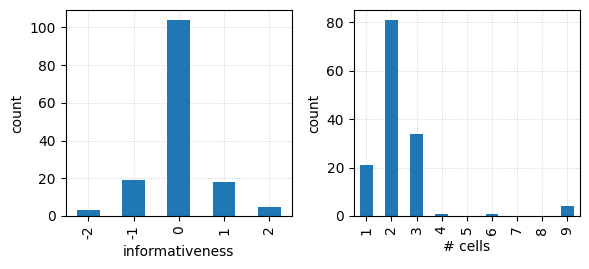

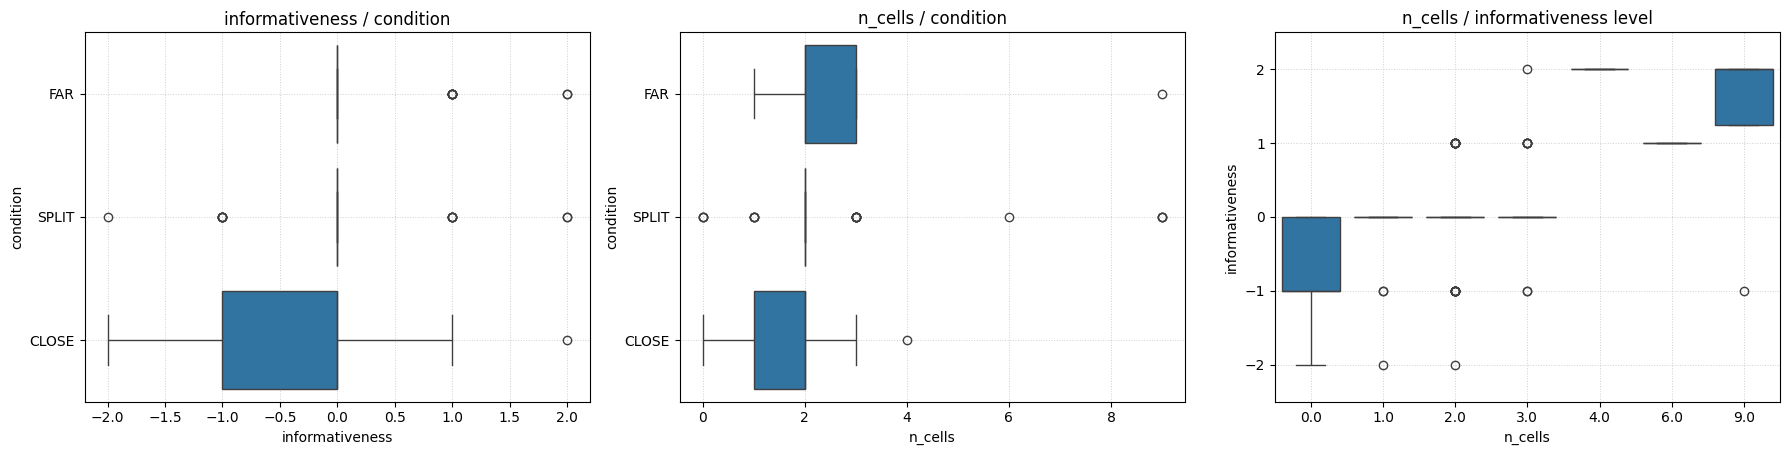





Processing system: Qwen3.5-27B-FP8






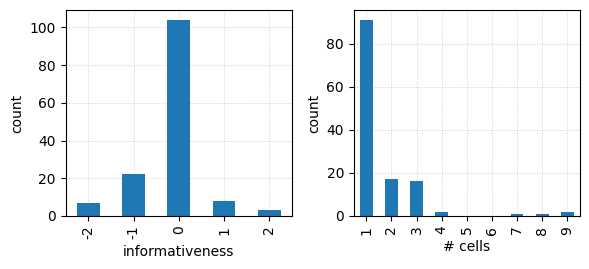

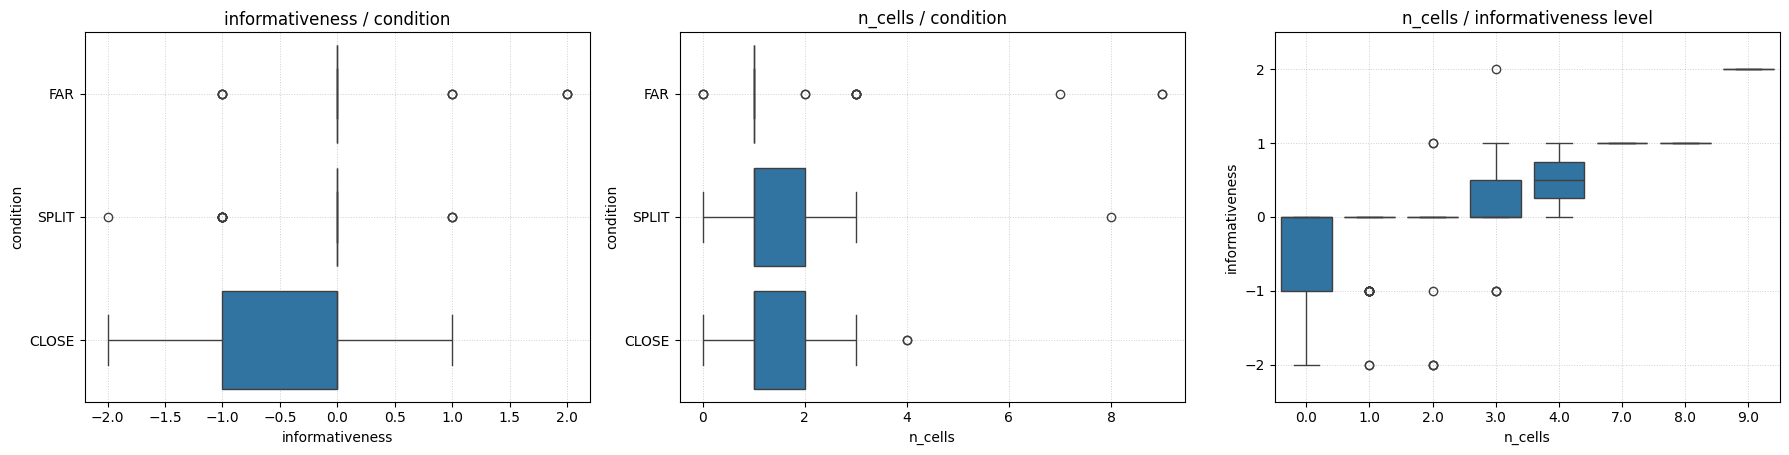





Processing system: Qwen3.5-4B-thinking






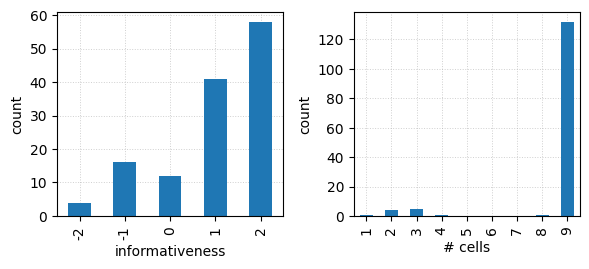

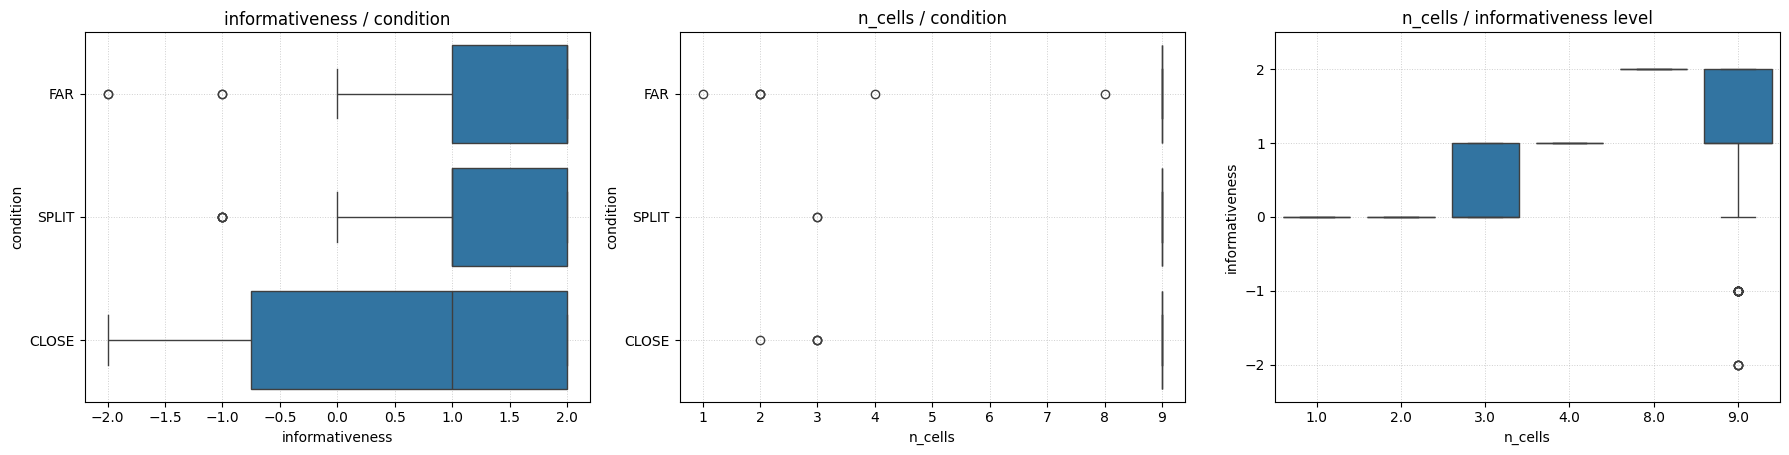





Processing system: Qwen3.5-4B






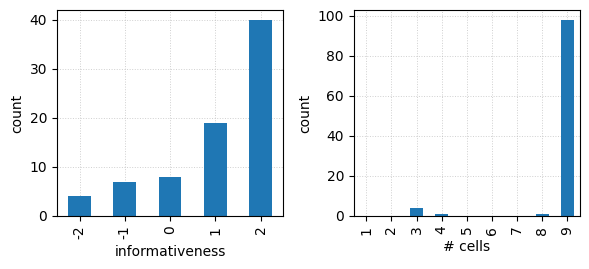

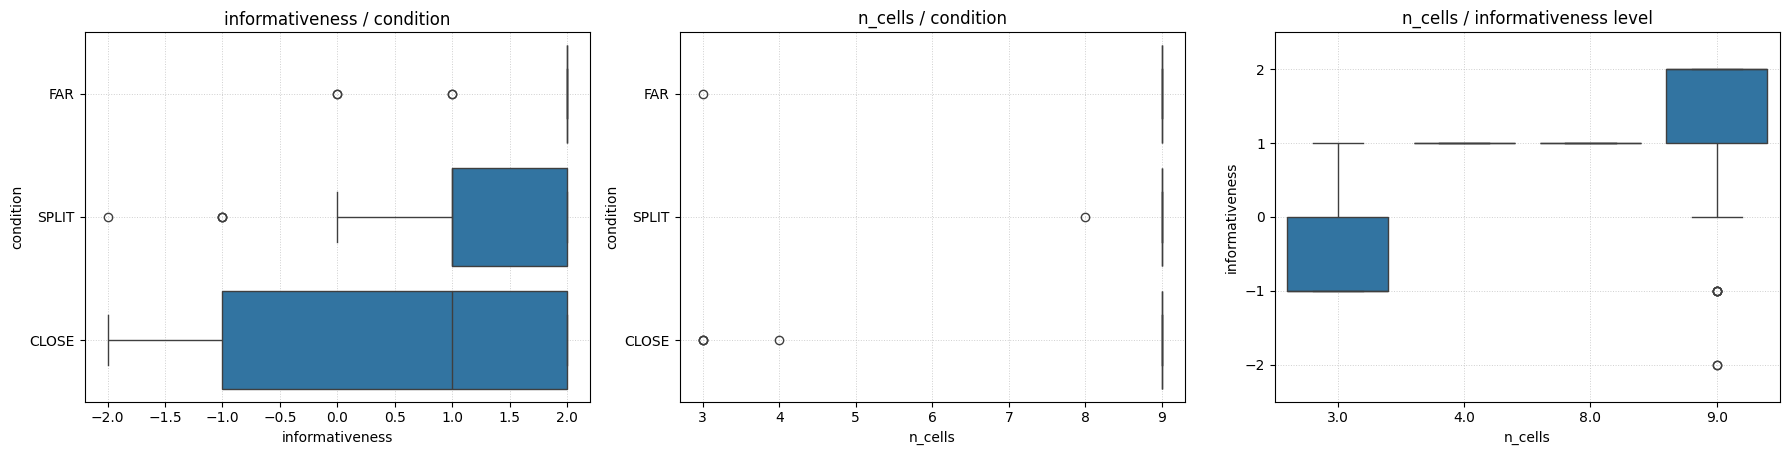





Processing system: Qwen3.5-9B-thinking






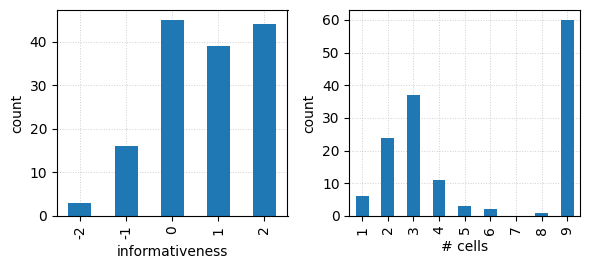

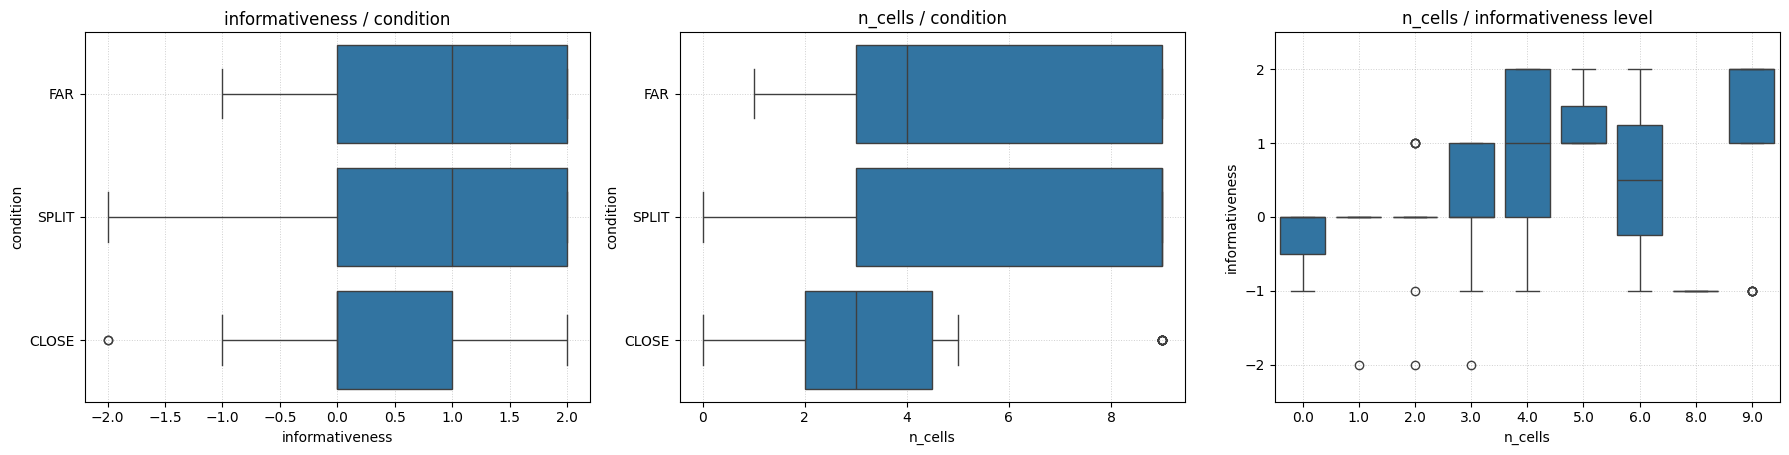





Processing system: Qwen3.5-9B






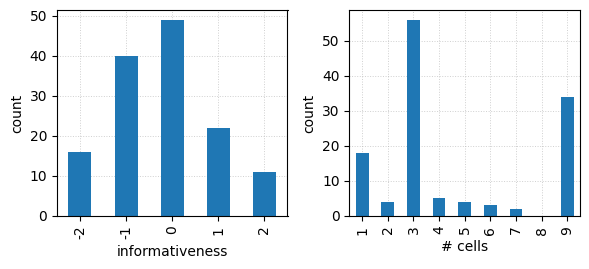

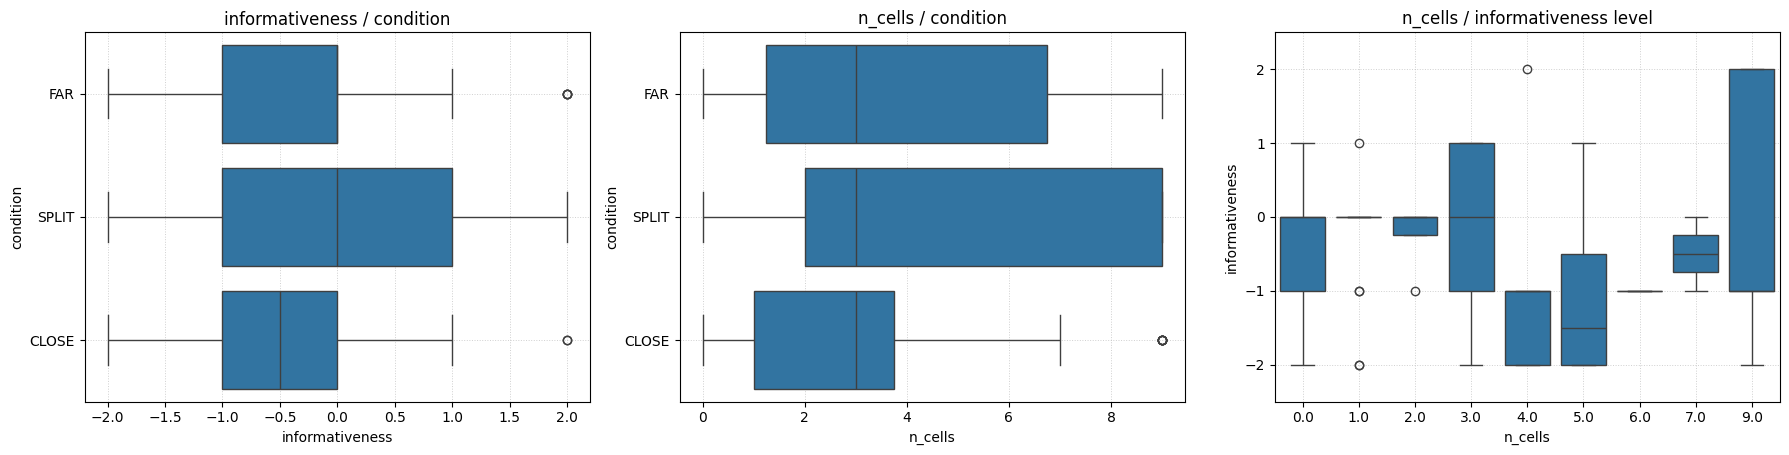





Processing system: Qwen3.6-27B-FP8-thinking






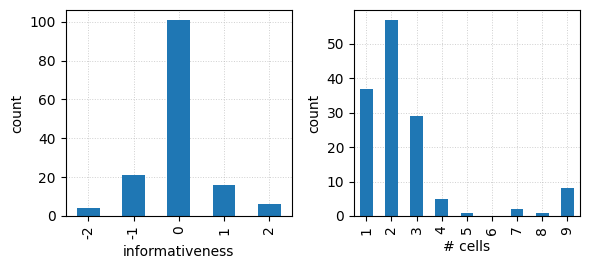

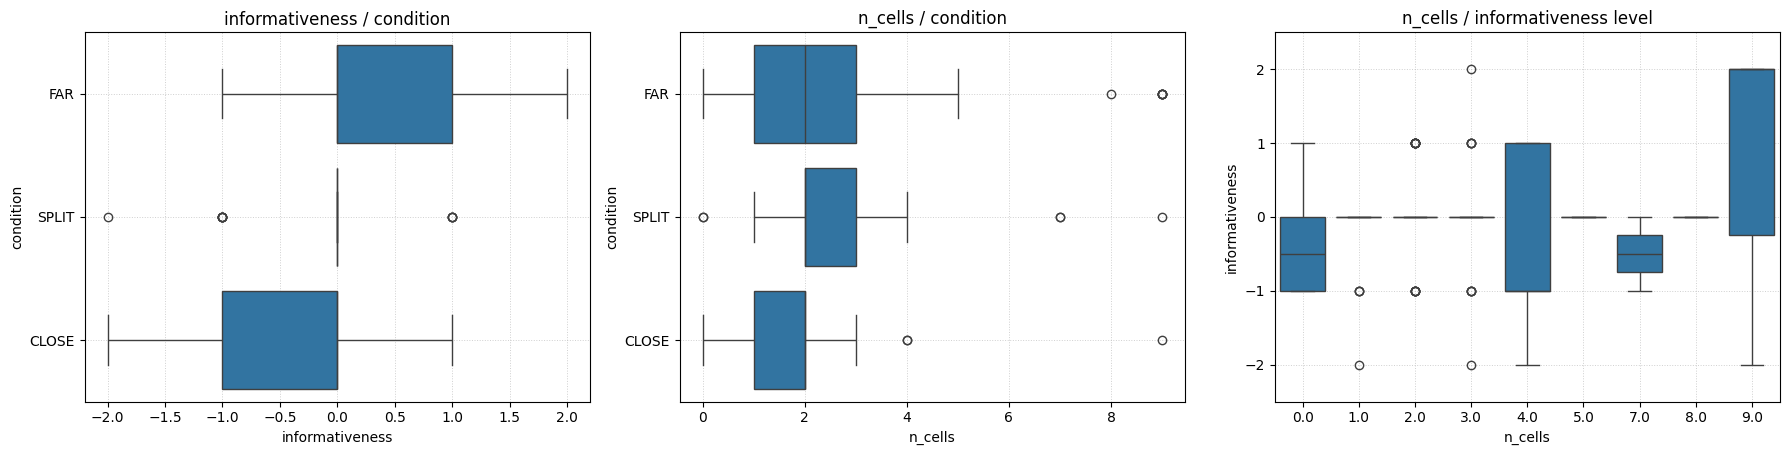





Processing system: Qwen3.6-27B-FP8






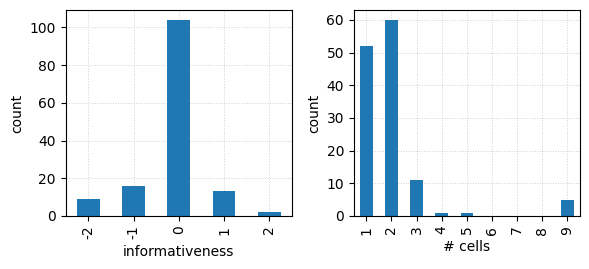

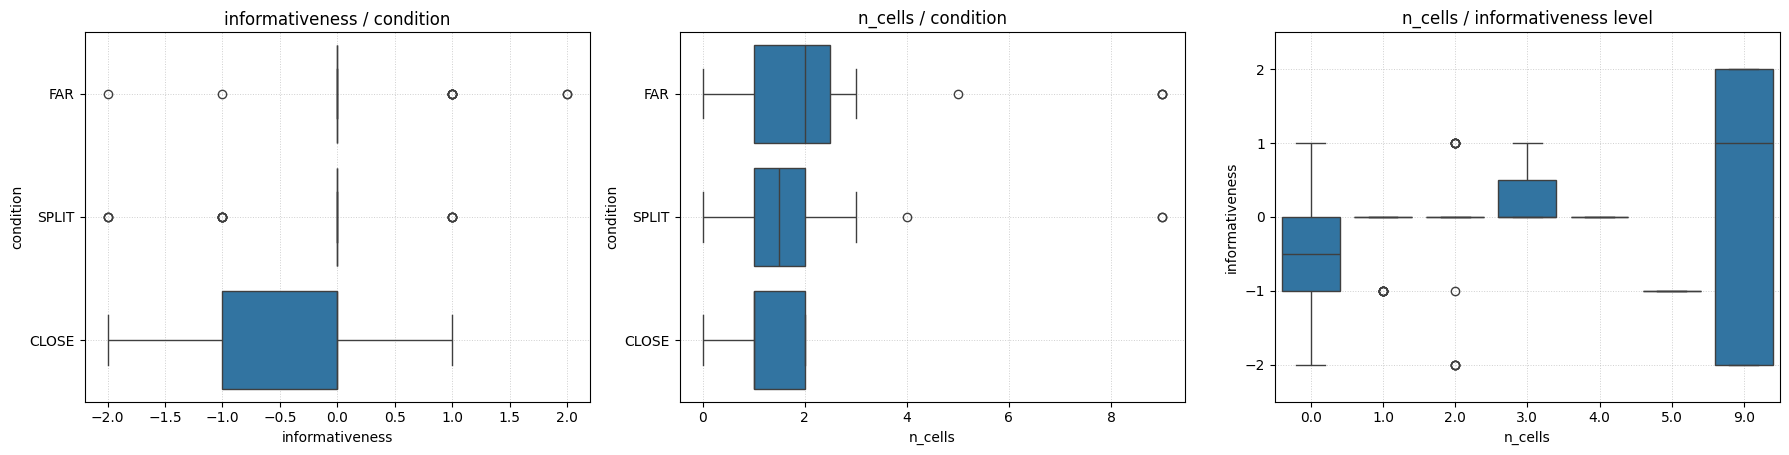





Processing system: human






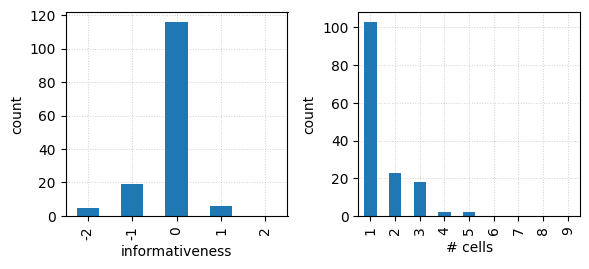

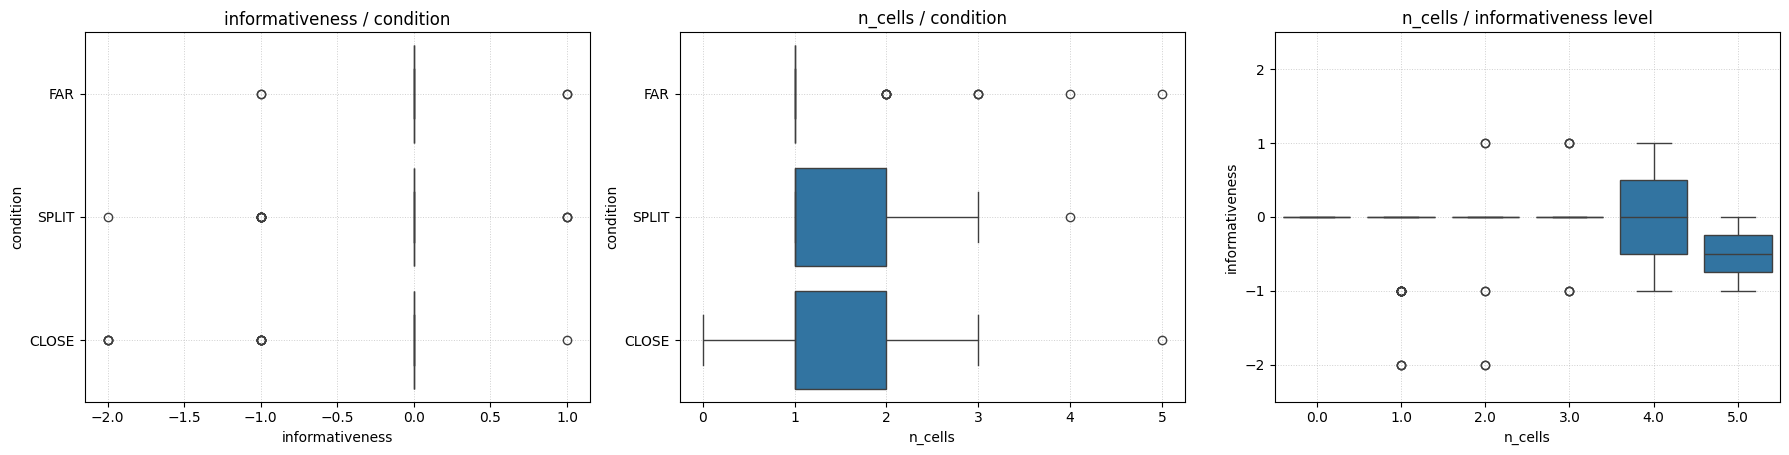





Processing system: gemma-4-12B-it-thinking






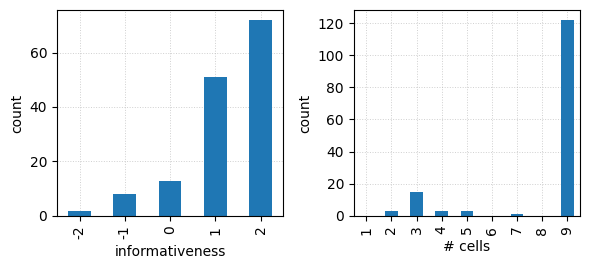

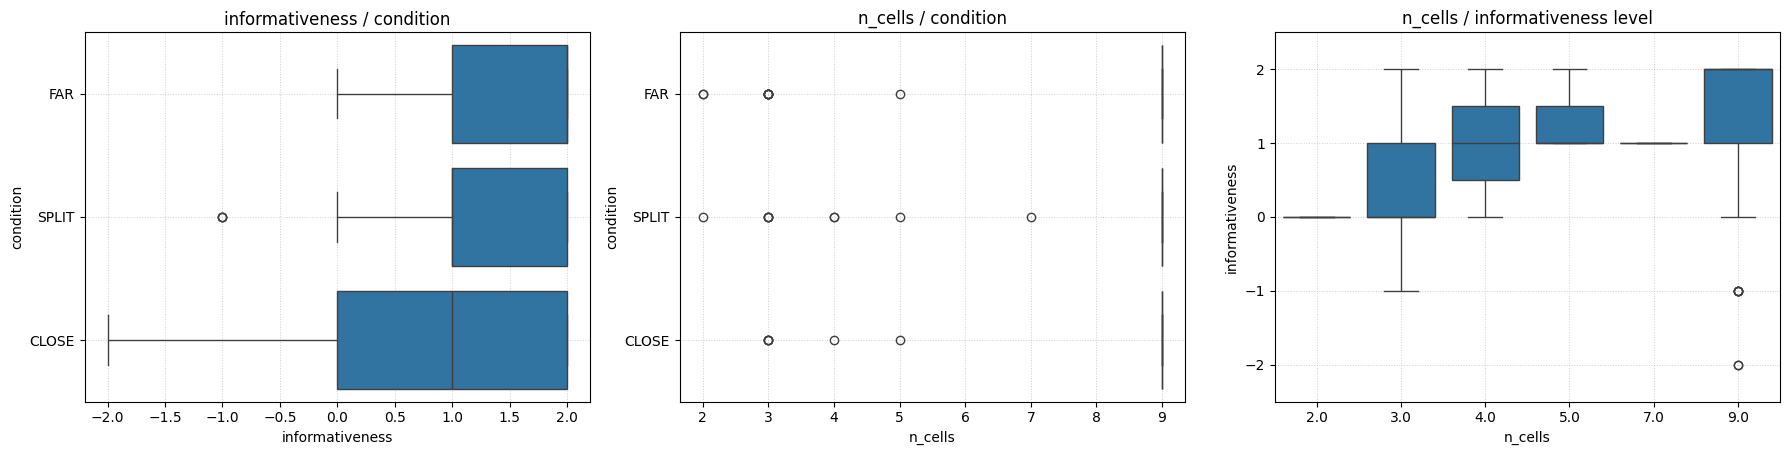





Processing system: gemma-4-12B-it






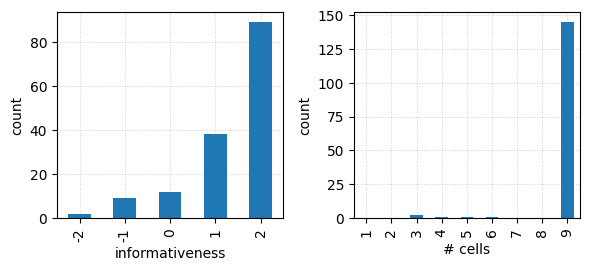

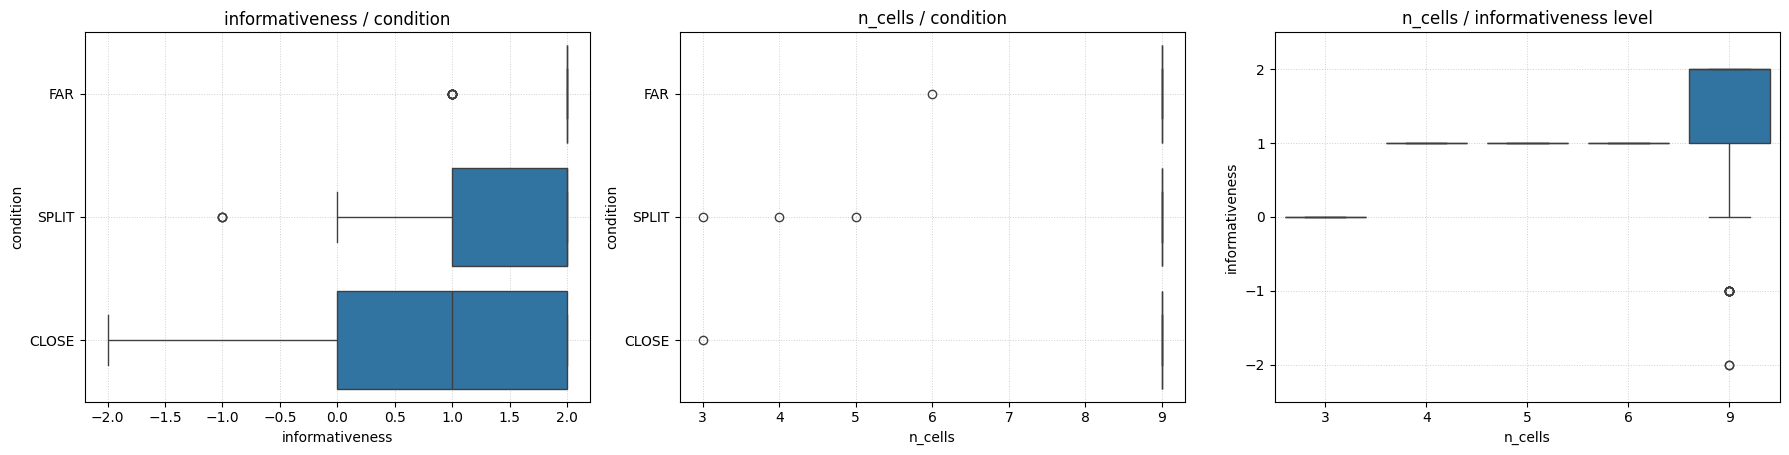





Processing system: gemma-4-26B-A4B-it-FP8-Dynamic-thinking






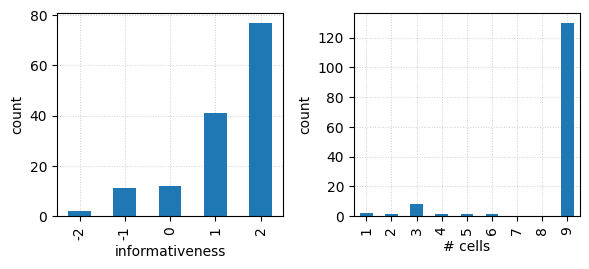

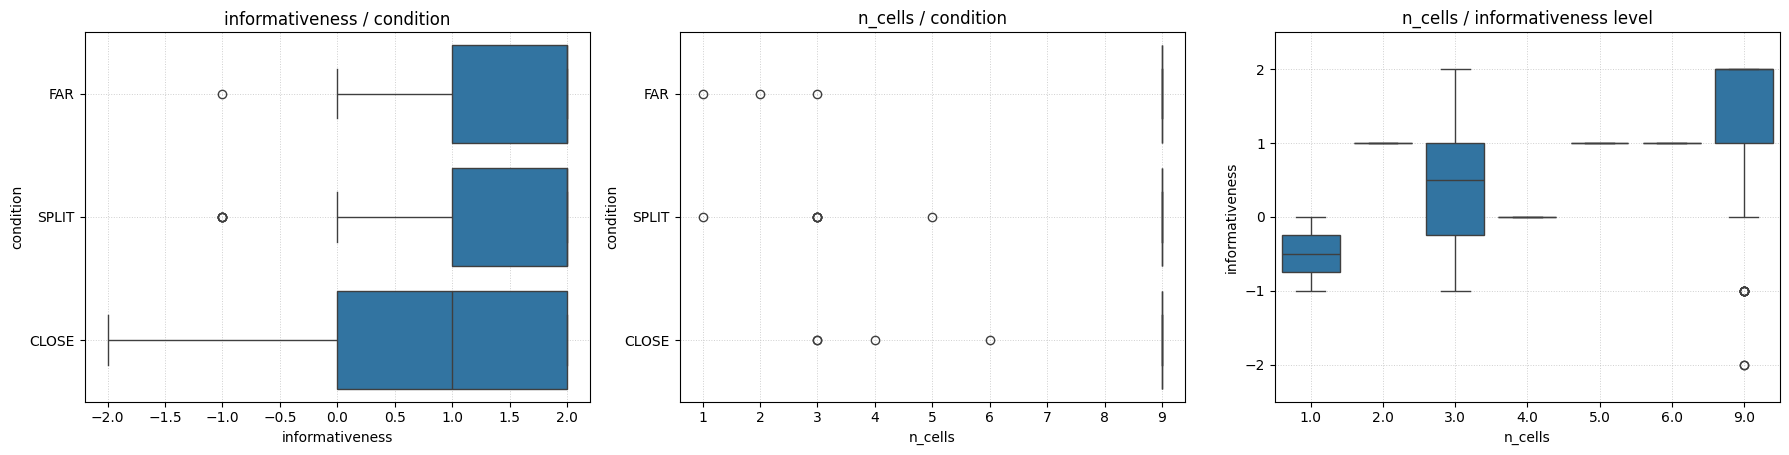





Processing system: gemma-4-26B-A4B-it-FP8-Dynamic






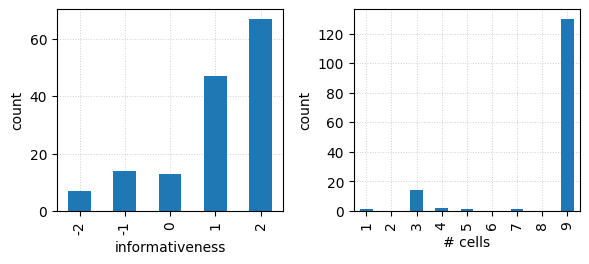

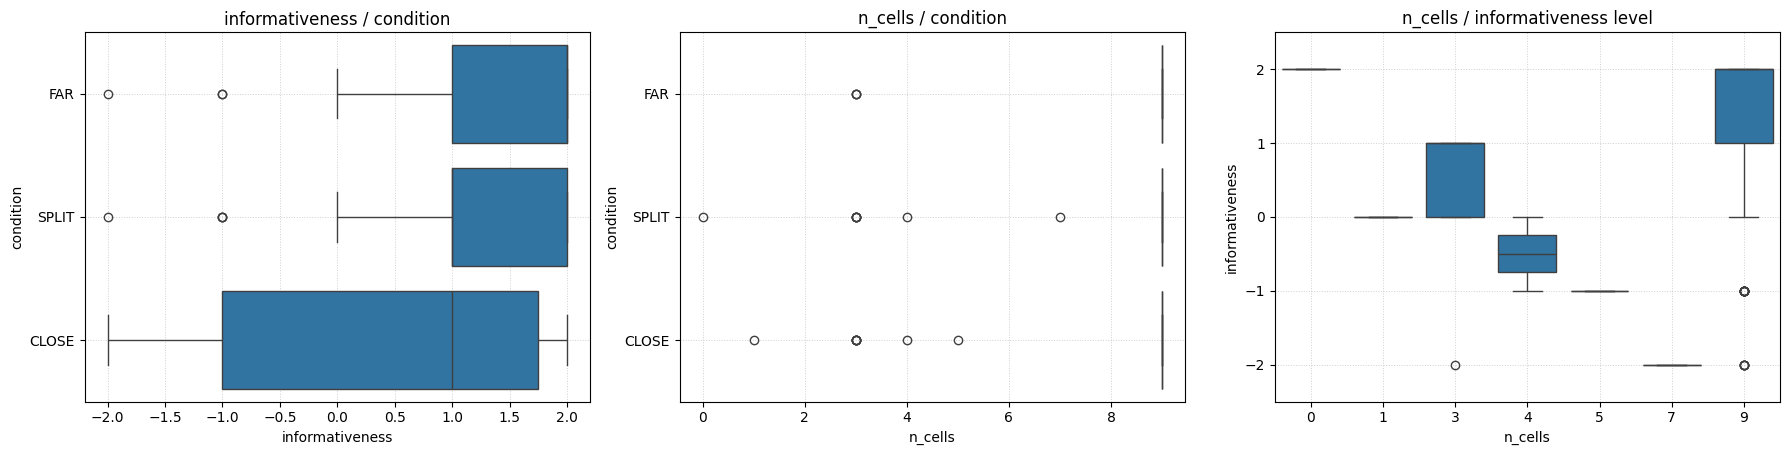





Processing system: gemma-4-E4B-it-thinking






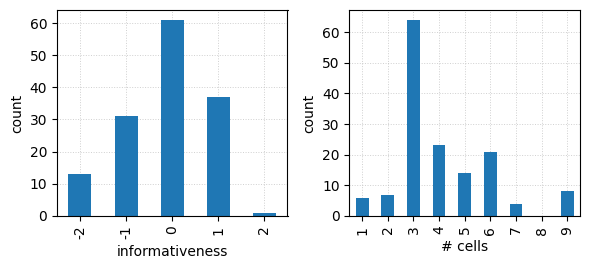

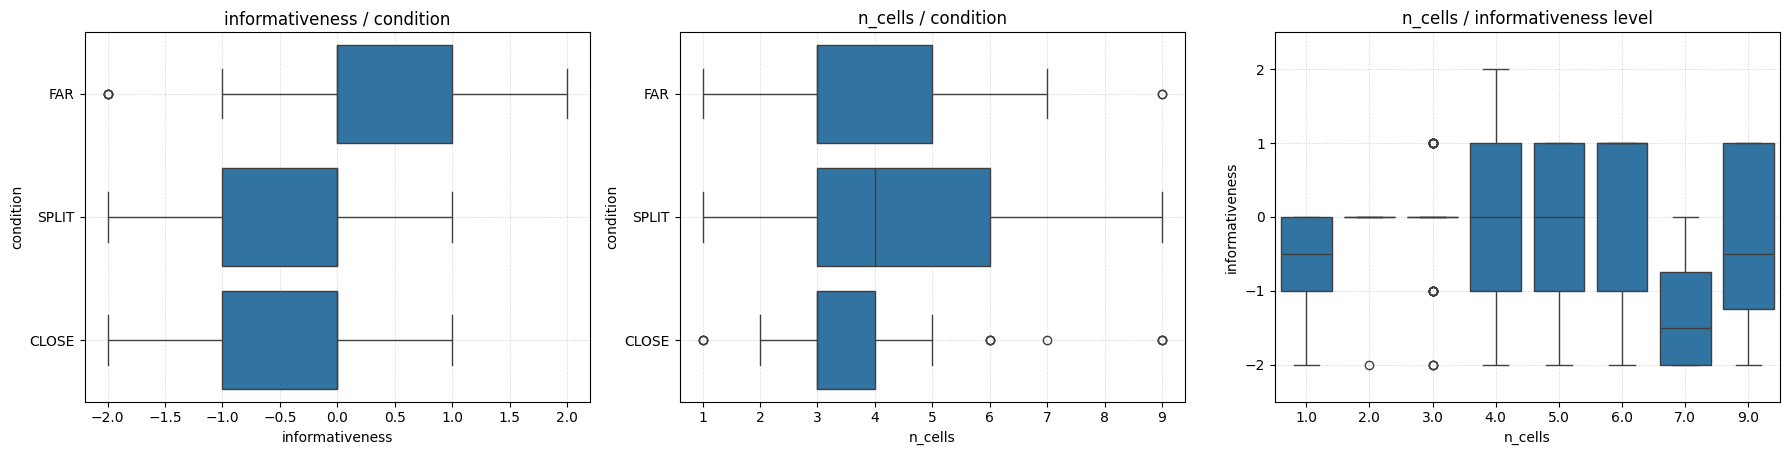





Processing system: gemma-4-E4B-it






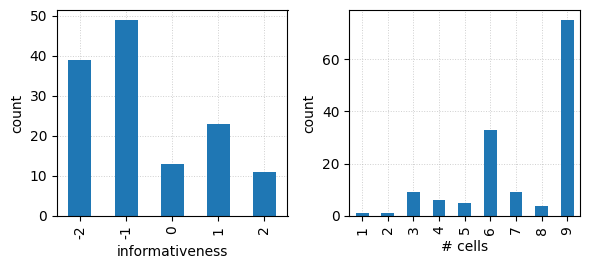

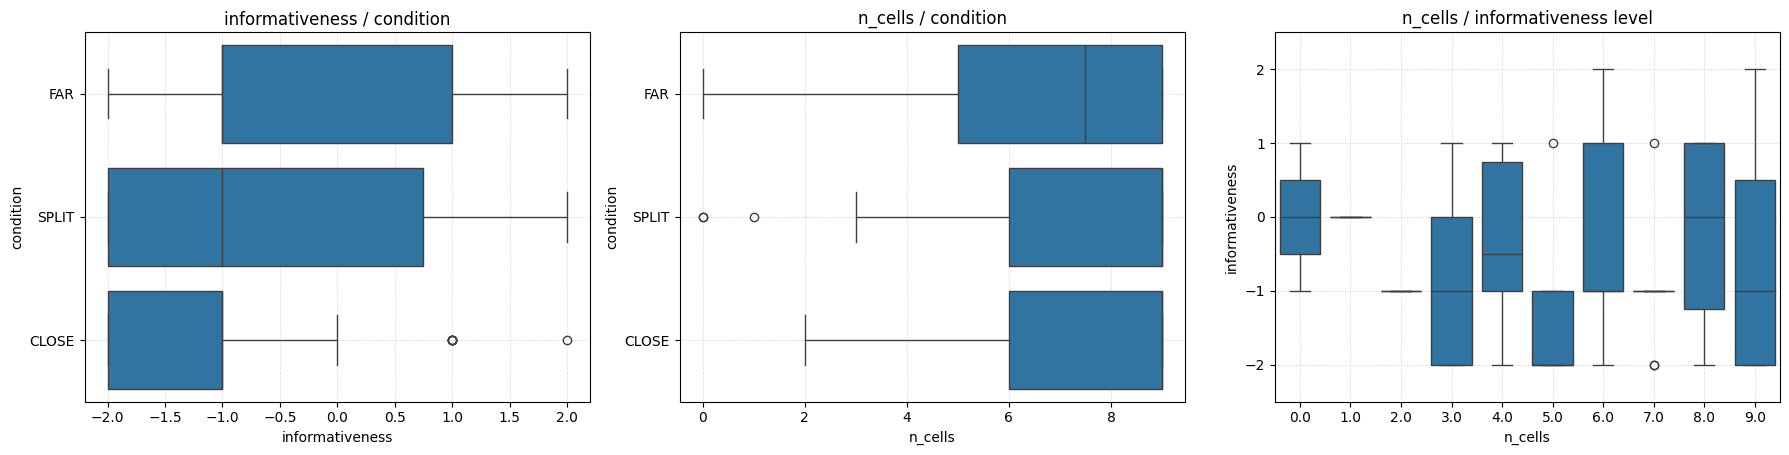

In [3]:
# create plots for each system (including human):
# 1. distributions of informativeness and n_cells
# 2. boxplots (or violin plots) of informativeness and n_cells by condition and n_cells by informativeness level
PLOT_TYPE = "box"

for system in systems:

    print("\n\n", "=" * 80, "\n\n")
    print(f"Processing system: {system}")
    print("\n\n", "=" * 80, "\n\n")

    # extract data
    system_human_evals = human_eval.loc[
        human_eval.system == system.replace("-thinking", "_thinking")
    ].set_index("target_id").loc[item_ids]
    system_informativeness = system_human_evals.description_informativeness.dropna()
    condition = system_human_evals.condition.dropna()

    system_descriptions = automatic_anns[f"{system}_description"].loc[item_ids].dropna()
    system_responses = automatic_anns[f"{system}_response"].loc[item_ids].dropna()
    system_cells = automatic_anns[f"{system}_cells"].loc[item_ids].dropna()
    system_n_cells = system_cells.map(len)

    # merge into a single dataframe for plotting
    inf_cell_df = pd.DataFrame(
        [
            condition,
            system_informativeness.rename("informativeness"),
            system_n_cells.rename("n_cells"),
        ]
    ).T

    #####################################################
    # 1. plot informativeness and n_cells distributions #
    #####################################################

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    # 1st subplot: informativeness distribution
    inf_cell_df.informativeness.value_counts().reindex(
        list(range(-2, 3)), fill_value=0
    ).plot(
        kind="bar",
        #title=f"Informativeness distribution ({system})",
        xlabel="informativeness",
        ylabel="count",
        ax=axes[0],
    )
    #axes[0].set_title("informativeness")

    # 2nd subplot: n_cells distribution
    inf_cell_df.n_cells.value_counts().reindex(list(range(1, 10)), fill_value=0).plot(
        kind="bar",
        #title=f"n_cells distribution ({system})",
        xlabel="# cells",
        ylabel="count",
        ax=axes[1],
    )
    #axes[1].set_title("# cells")

    # grid formatting
    for ax in axes:
        ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
        ax.set_axisbelow(True)  # keep grid lines behind the bars

    # finalize and show
    #fig.suptitle(system, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(osp.join(FIG_SAVE_DIR, f"{system}_distributions.{FIG_FORMAT}"), format=FIG_FORMAT)
    plt.show()

    ######################################################################
    # 2. plot boxplots (or violin plots) for informativeness and n_cells #
    ######################################################################

    plot = {"box": sns.boxplot, "violin": sns.violinplot}.get(PLOT_TYPE)
    args = {
        "box": dict(),
        "violin": {"cut": 0, "inner": "box"},
    }.get(PLOT_TYPE)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    condition_order = ["FAR", "SPLIT", "CLOSE"]

    # 1st subplot: informativeness by condition
    plot(
        data=inf_cell_df,
        x="informativeness",
        y="condition",
        ax=axes[0],
        order=condition_order,
        **args,
    )
    axes[0].set_title("informativeness / condition")

    # 2nd subplot: n_cells by condition
    plot(
        data=inf_cell_df,
        x="n_cells",
        y="condition",
        ax=axes[1],
        order=condition_order,
        **args,
    )
    axes[1].set_title("n_cells / condition")

    # 3rd subplot: n_cells by informativeness level
    plot(data=inf_cell_df, x="n_cells", y="informativeness", ax=axes[2], **args)
    axes[2].set_ylim(-2.5, 2.5)
    axes[2].set_title("n_cells / informativeness level")

    # grid formatting
    for ax in axes:
        ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
        ax.set_axisbelow(True)  # keep grid lines behind the bars

    # finalize and show
    #fig.suptitle(system, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    #plt.savefig(osp.join(FIG_SAVE_DIR, f"{system}_boxplots.{FIG_FORMAT}"), format=FIG_FORMAT)
    plt.show()